In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

First - look at correlation so success (target variable)

In [ ]:
df00 = pd.read_csv('dataset-of-00s.csv')
df10 = pd.read_csv('dataset-of-10s.csv')
df90 = pd.read_csv('dataset-of-90s.csv')

data = pd.concat([df90, df00, df10], ignore_index=True)
print(data.columns)
columns_corr = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
                'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target']

data_num = data[columns_corr]

Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'target'],
      dtype='object')


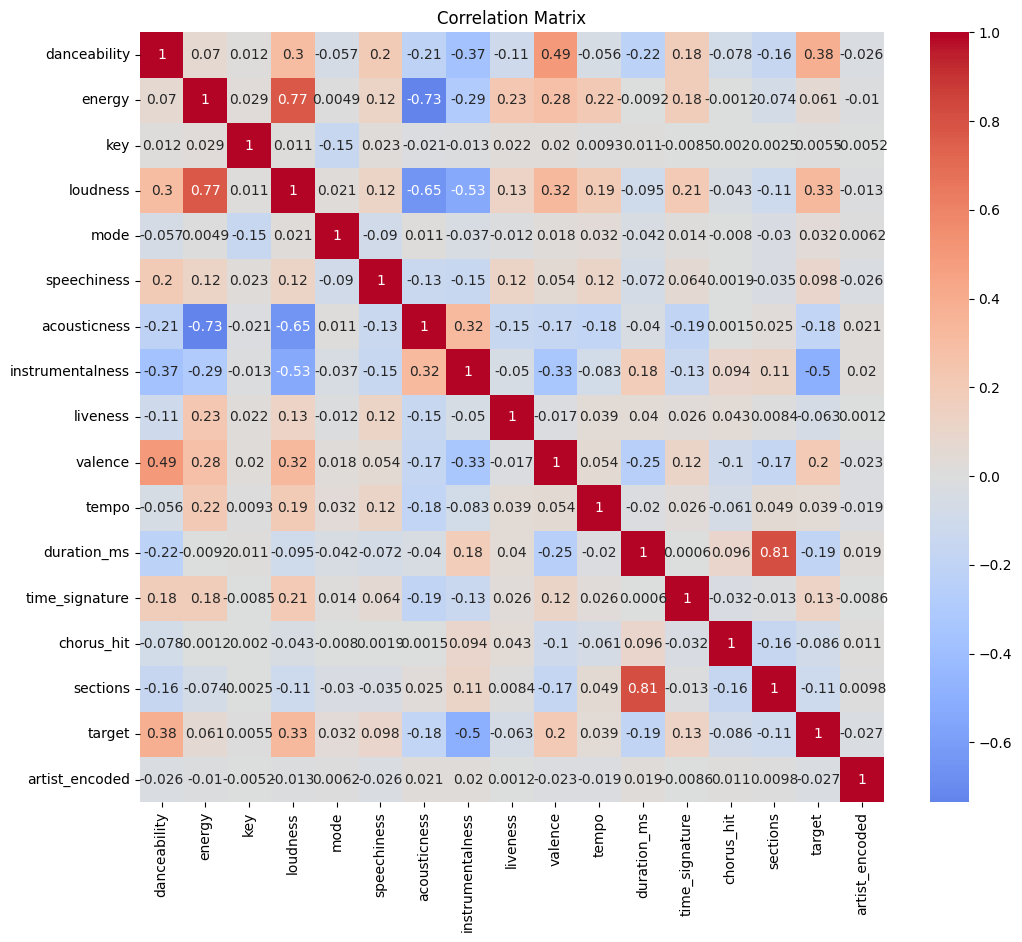

In [76]:
corr_matrix = data_num.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [77]:
#artists are very strcictly correlated with target, only 13 artists have songs in both classes, so we can not use it as a feature, but we can encode it using target encoding
#print(data.groupby('artist')['target'].nunique().value_counts())
#print((data.groupby('artist')['target'].nunique() > 1).sum())
(data.groupby('artist')['target'].nunique() > 1).sum()

13

most valuable features


In [83]:
corr = abs(data_num.corr(numeric_only=True)['target']).sort_values(ascending=False)
print(corr)
best_features = corr[1:7].index
print(best_features)

target              1.000000
instrumentalness    0.499624
danceability        0.384486
loudness            0.327471
valence             0.203774
duration_ms         0.189203
acousticness        0.184479
time_signature      0.127544
sections            0.113383
speechiness         0.097783
chorus_hit          0.085587
liveness            0.062612
energy              0.060701
tempo               0.039226
mode                0.032021
artist_encoded      0.027294
key                 0.005548
Name: target, dtype: float64
Index(['instrumentalness', 'danceability', 'loudness', 'valence',
       'duration_ms', 'acousticness'],
      dtype='object')


C:\Users\Marcel\AppData\Local\Temp\ipykernel_23232\1827937171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_features_df['target'] = data['target']


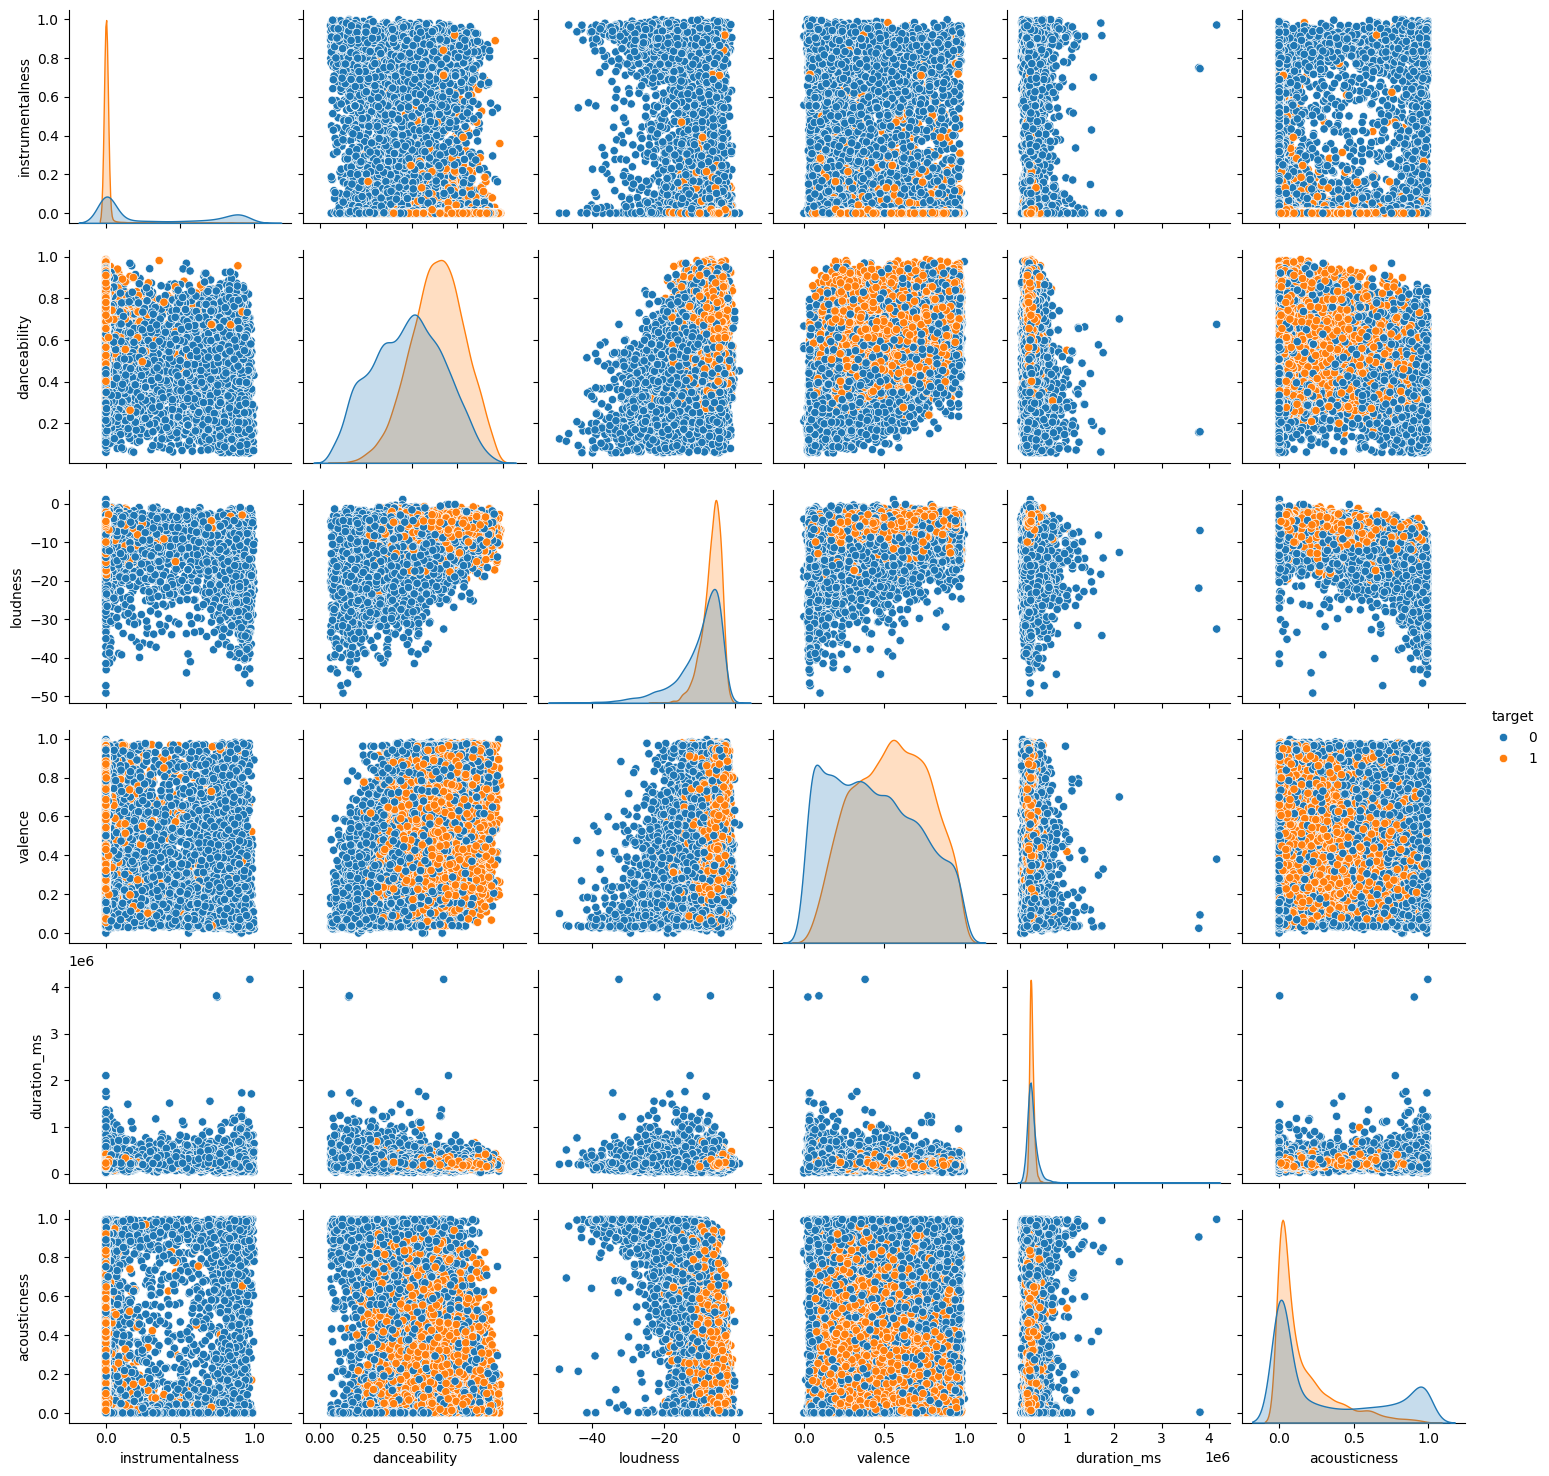

In [85]:
best_features_df = data[best_features]
best_features_df['target'] = data['target']
sns.pairplot(best_features_df, hue='target')
plt.show()